# Bagging - Ensemble Learning

### What is Bagging?

**Bagging** (short for **Bootstrap Aggregating**) is an ensemble learning technique that trains multiple models independently on different random subsets of the training data and then combines their predictions to produce a final result.

The key idea is simple: instead of training one model on all the data, we train several models, each on a slightly different random sample drawn **with replacement** from the original dataset. When predicting, each model votes, and the majority vote wins.

---

### Why use Bagging?

A single decision tree tends to **overfit** - it memorises the training data rather than learning general patterns. This is called **high variance**. Bagging directly reduces this variance by averaging out the quirks of many trees trained on different data samples.

- Each tree sees a slightly different version of the training data.
- No single noisy sample dominates all models.
- When combined, the ensemble is more stable and generalises better.

---

### How Bagging Works (Step by Step)

1. **Bootstrap Sampling** - Randomly draw samples from the training set *with replacement*. This means the same data point can appear more than once in a sample, and some points may not appear at all.
2. **Train** - Train an independent model (in this notebook, a Decision Tree) on each bootstrap sample.
3. **Predict** - Each model makes its own prediction on new data.
4. **Aggregate** - For classification, take the **majority vote** across all models. For regression, take the **average**.


In [93]:
import warnings 
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

### Load the Dataset

Use the **Iris dataset**, which contains measurements of flowers from three different species:
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Each row records four measurements (sepal length, sepal width, petal length, petal width) in centimetres, plus the species label.

Drop the `Id` column because it carries no predictive information - it is just a row identifier.

In [95]:
data = pd.read_csv("Iris.csv")
data = data.drop(columns=['Id'])
data.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa


### Label Encoding

The `Species` column currently holds string values like `"Iris-setosa"`. Machine learning models work with numbers, not text, so need to convert these strings into integer codes.

**LabelEncoder** does exactly that. It assigns a unique integer to each class:
- `Iris-setosa` -> `0`
- `Iris-versicolor` -> `1`
- `Iris-virginica` -> `2`


In [97]:
encoder = LabelEncoder()
data['Species'] = encoder.fit_transform(data['Species'])
data.sample(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
44,5.1,3.8,1.9,0.4,0
40,5.0,3.5,1.3,0.3,0
49,5.0,3.3,1.4,0.2,0


### Simplify to Binary Classification

Bagging (and decision boundaries in 2D) are easier to understand when there are only **two classes**. Therefore filter the dataset to keep only species `1` (*Iris-versicolor*) and `2` (*Iris-virginica*), and drop class `0` (*Iris-setosa*).

In [99]:
data = data[data['Species']!=0][['SepalWidthCm','PetalLengthCm','Species']]
data.head(2)

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1


###  Visualise the Data

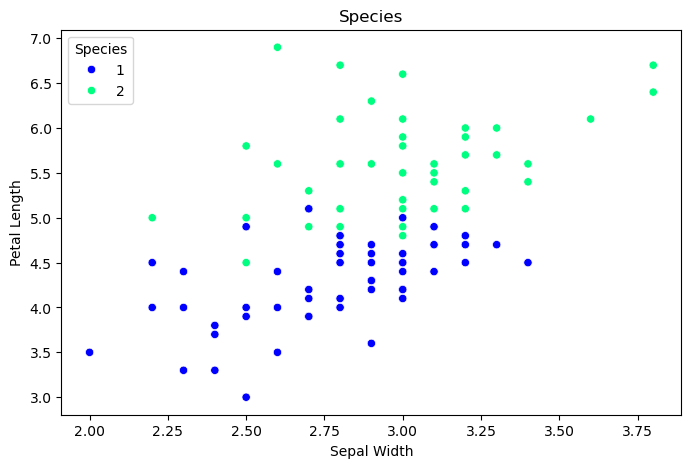

In [131]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data,x='SepalWidthCm',y='PetalLengthCm', hue='Species', palette='winter')
plt.xlabel('Sepal Width')
plt.ylabel('Petal Length')
plt.title('Species')
plt.show()

### Create Train, Validation, and Test Splits
- The full dataset is shuffled.
- The first 60 rows form the **training pool**, from which we randomly pick 10 samples.
- Rows 60-80 form the **validation set**, from which we randomly pick 5 samples.
- Rows 80 onward form the **test set**, from which we randomly pick 5 samples.

In [103]:
data = data.sample(100)
data_train = data.iloc[:60,:].sample(10)
data_val = data.iloc[60:80,:].sample(5)
data_test = data.iloc[80:,:].sample(5)

In [104]:
X_test = data_val.iloc[:,0:2].values
y_test = data_val.iloc[:,-1].values

### Initialise Three Decision Tree Classifiers

In Bagging we need multiple independent base learners. Here we create **three separate Decision Tree classifiers**. 

> Using `DecisionTreeClassifier()` with default settings means each tree is allowed to grow as deep as needed to perfectly fit its training sample. This intentional overfitting on each individual sample is fine because the ensemble averages it out.

In [106]:
Decision_tree_bag_1 = DecisionTreeClassifier()
Decision_tree_bag_2 = DecisionTreeClassifier()
Decision_tree_bag_3 = DecisionTreeClassifier()

### Define the Evaluation Function

Define a reusable helper function called `evaluate`.

Given a classifier and a training set `(X, y)`, the function:
1. **Trains** the classifier on `(X, y)`.
2. **Plots the decision tree structure** - this shows how the tree split the data into regions.
3. **Plots the 2D decision boundary** - this visualises which part of the feature space the tree assigns to each class.
4. **Measures accuracy** on the held-out validation set (`X_test`, `y_test`).

In [108]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plt.figure(figsize=(14,6))
    plt.subplot(121)
    plot_tree(clf)
    
    plt.subplot(122)
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    plt.tight_layout()
    plt.show()
    
    y_pred = clf.predict(X_test)
    print("\n Accuracy Score For Decision Tree Bagging ::",accuracy_score(y_test,y_pred))

### Train and Evaluate the First Bagging Tree

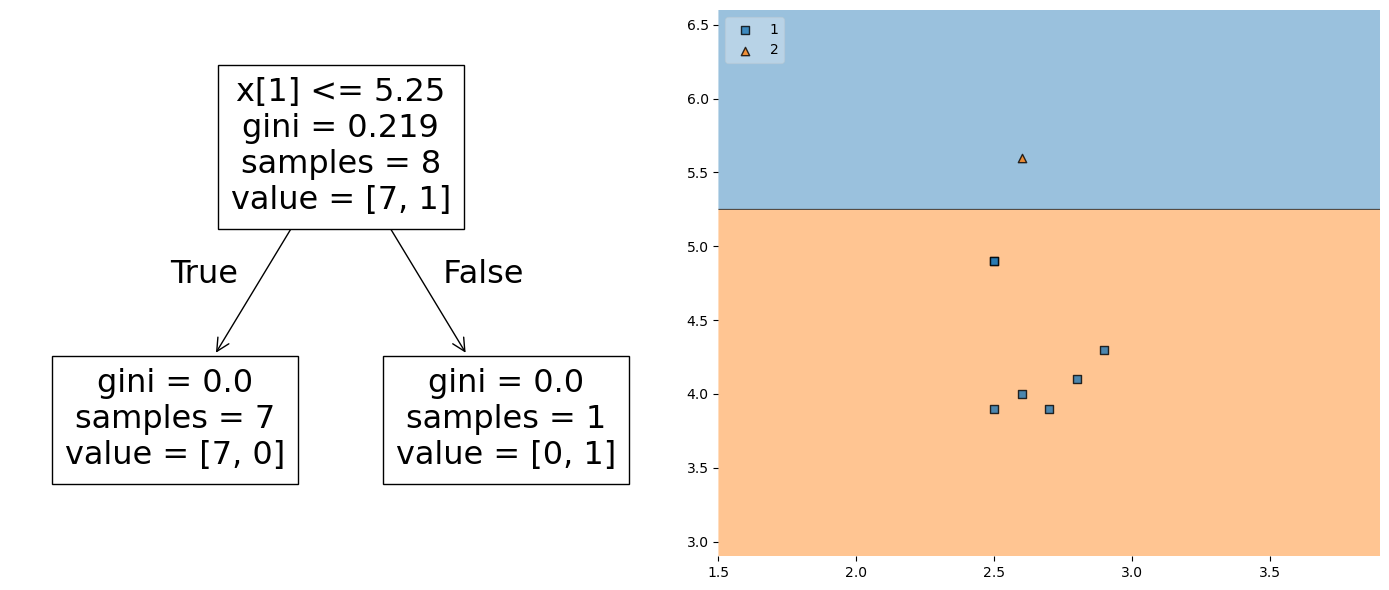


 Accuracy Score For Decision Tree Bagging :: 1.0


In [110]:
data_bag_1 = data_train.sample(8,replace=True)
X = data_bag_1.iloc[:,0:2]
y = data_bag_1.iloc[:,-1]
evaluate(Decision_tree_bag_1,X,y)

### Train and Evaluate the Second Bagging Tree

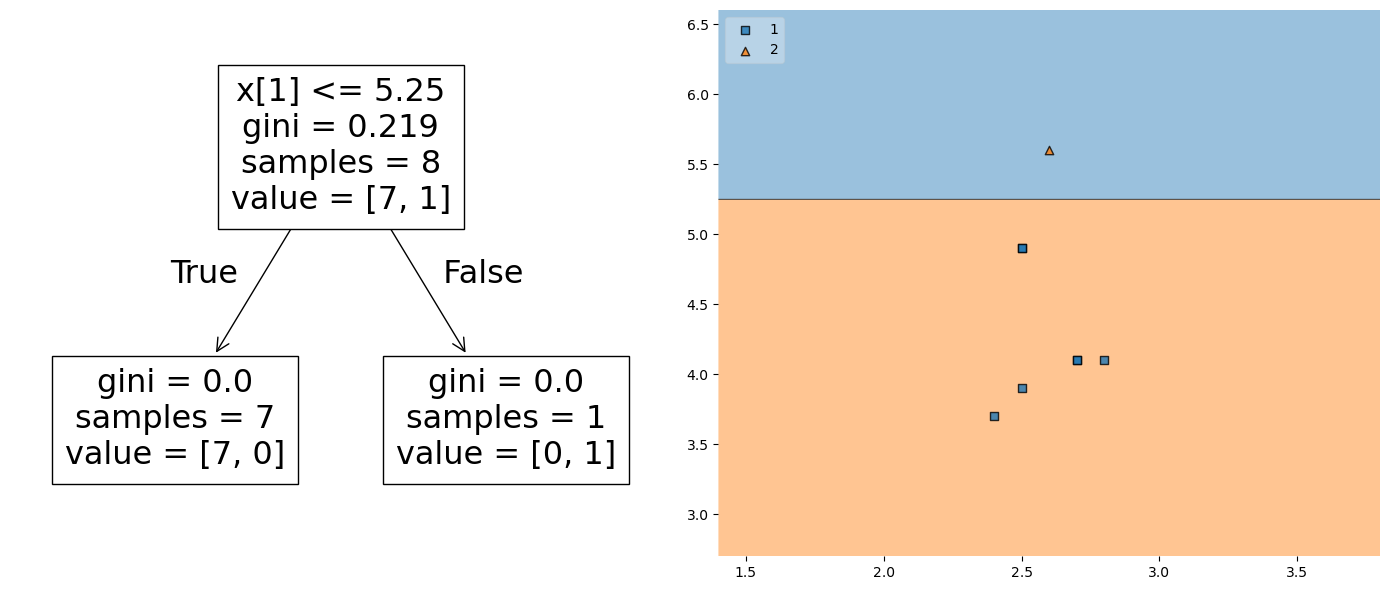


 Accuracy Score For Decision Tree Bagging :: 1.0


In [112]:
data_bag_2 = data_train.sample(8,replace=True)
X = data_bag_2.iloc[:,0:2]
y = data_bag_2.iloc[:,-1]
evaluate(Decision_tree_bag_2,X,y)

### Train and Evaluate the Third Bagging Tree

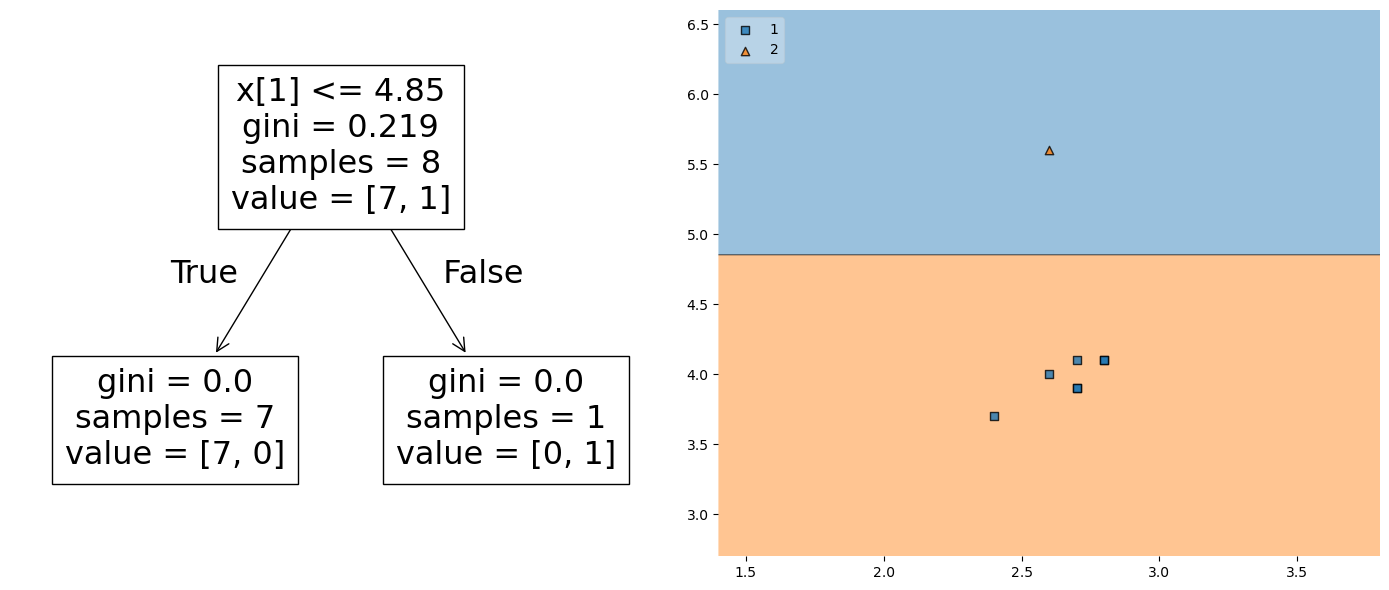


 Accuracy Score For Decision Tree Bagging :: 1.0


In [114]:
data_bag_3 = data_train.sample(8,replace=True)
X = data_bag_3.iloc[:,0:2]
y = data_bag_3.iloc[:,-1]
evaluate(Decision_tree_bag_3,X,y)

### Predictions

In [116]:
print("Prediction 1 ::",Decision_tree_bag_1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Prediction 2 ::",Decision_tree_bag_2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Prediction 3 ::",Decision_tree_bag_3.predict(np.array([2.2,5.0]).reshape(1,2)))

Prediction 1 :: [1]
Prediction 2 :: [1]
Prediction 3 :: [2]
